Tareas a Realizar

1️. Identificación de Tipos de Datos

- Clasifica cada columna según su tipo (numérico, categórico, ordinal, fecha) y explica cómo se debería manejar cada una.

2️. Limpieza de Datos

-     Detecta y corrige valores faltantes en las columnas necesarias.

-     Identifica y elimina valores atípicos en la columna “Salario”.

-     Corrige inconsistencias en los datos categóricos (ejemplo: "Licenciado" y "licenciado" deben ser tratados como el mismo valor).

3️. Transformación de Datos

-     Convierte las variables categóricas en numéricas utilizando codificación ordinal o One-Hot Encoding.

-     Aplica normalización al salario para facilitar comparaciones.

-     Crea una nueva variable “Años hasta jubilación” suponiendo que la edad de retiro es 65 años.

4️. Análisis Exploratorio con LLM

Usa ChatGPT o una herramienta LLM para ayudarte en alguna de estas tareas:

-     Generar un resumen de los datos.

-     Explicar cómo manejar valores faltantes.

-     Sugerir formas de visualizar los datos.

Ejemplo de consulta a ChatGPT:

"Tengo un dataset con sueldos y edades, ¿cómo puedo detectar y eliminar outliers en Python?"

Comparte en el foro la consulta que hiciste y la respuesta que te dio el LLM.

In [75]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

# Cargar los datos
df = pd.DataFrame({
"ID": [1, 2, 3, 4, 5],
"Nombre": ["Juan", "María", "Pedro", "Ana", "Luis"],
"Edad": [32, -28, 40, 35, 50],
"Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
"Salario": [50000, 60000, None, 55000, 200000],
"Categoría": ["Junior", "Senior", "Senior", "Junior", "Manager"],
"Estado": ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"]
})

# 1️ Corrección de edad negativa
df["Edad"] = df["Edad"].abs()

# 2️ Imputación del salario faltante con la mediana
df["Salario"].fillna(df["Salario"].median(), inplace=True)

# 3️ Detectar y eliminar valores atípicos con IQR
Q1, Q3 = df["Salario"].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[~((df["Salario"] < (Q1 - 1.5 * IQR)) | (df["Salario"] > (Q3 + 1.5 * IQR)))]

# 4️ Codificación ordinal para "Nivel Educativo"
encoder_ordinal = OrdinalEncoder(categories=[["Licenciado", "Ingeniero", "Doctorado"]])
df["Nivel_Cod"] = encoder_ordinal.fit_transform(df[["Nivel_Educativo"]])

# 5️ Normalización del salario
scaler = MinMaxScaler()
df["Salario_Normalizado"] = scaler.fit_transform(df[["Salario"]])

# 6️ Creación de nueva variable "Años hasta jubilación"
df["Años_Hasta_Jubilación"] = 65 - df["Edad"]
print(df)

   ID Nombre  Edad Nivel_Educativo  Salario Categoría    Estado  Nivel_Cod  \
0   1   Juan    32      Licenciado  50000.0    Junior    Activo        0.0   
1   2  María    28       Ingeniero  60000.0    Senior    ACTIVO        1.0   
2   3  Pedro    40       Doctorado  57500.0    Senior  Inactivo        2.0   
3   4    Ana    35      Licenciado  55000.0    Junior    Activo        0.0   

   Salario_Normalizado  Años_Hasta_Jubilación  
0                 0.00                     33  
1                 1.00                     37  
2                 0.75                     25  
3                 0.50                     30  


/tmp/ipykernel_15299/4148128099.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Salario"].fillna(df["Salario"].median(), inplace=True)


In [76]:
# 1 - Identificación de tipos de datos.
print(df.dtypes)
print("\n") #Baja

# Cambio el tipo de dato de "Categoria"
df["Categoría"] = df["Categoría"].astype("category")

# Cambio el tipo de dato de "Nivel de Educación"
df["Nivel_Educativo"] = df["Nivel_Educativo"].astype("category")

# Cambio el tipo de dato de "Estado" a Objeto
df["Estado"] = df["Estado"].astype("object")

# Compruebo los cambios realizados
print("\n") #bajo un renglon
print(df.dtypes)


# Clasifico los tipos de datos
dato_numerico = list(df.select_dtypes(include=['int64', 'float64']).columns)
dato_fecha = list(df.select_dtypes(include=['datetime64']).columns)
dato_categorico = list(df.select_dtypes(include=['object', 'category']).columns)
dato_ordinal = list(df.select_dtypes(include=['category']).columns)


#Utilice ayuda de la IA para separar los elementos de las listas ordinales y categoricos
dato_categorico = [x for x in dato_categorico if x not in dato_ordinal]


#Por ultimo muestro todas las listas
print("\n") #bajo un renglon
print("Los datos numéricos son: ", dato_numerico)
print("Los datos categóricos son: ", dato_categorico)
print("Los datos ordinales son: ", dato_ordinal)
print("Los datos tipo fecha son: ", dato_fecha)


ID                         int64
Nombre                    object
Edad                       int64
Nivel_Educativo           object
Salario                  float64
Categoría                 object
Estado                    object
Nivel_Cod                float64
Salario_Normalizado      float64
Años_Hasta_Jubilación      int64
dtype: object




ID                          int64
Nombre                     object
Edad                        int64
Nivel_Educativo          category
Salario                   float64
Categoría                category
Estado                     object
Nivel_Cod                 float64
Salario_Normalizado       float64
Años_Hasta_Jubilación       int64
dtype: object


Los datos numéricos son:  ['ID', 'Edad', 'Salario', 'Nivel_Cod', 'Salario_Normalizado', 'Años_Hasta_Jubilación']
Los datos categóricos son:  ['Nombre', 'Estado']
Los datos ordinales son:  ['Nivel_Educativo', 'Categoría']
Los datos tipo fecha son:  []


Los tipos de datos numéricos pueden ser utilizados para modelos de predicción, se utilizan gráficos como histogramas, diagramas de dispersión, y boxplots.

Los tipos de datos categóricos no tienen un orden de jerarquía. En el caso de Estado podría observar con un Gráfico de Barras para poder comparar y a la vez separar los datos "Activos" de los "Inactivos". Otra opción son los gráficos de torta aunque personalmente es más sencillo de entender el de barras.


Por otro lado los tipos ordinales podemos transformarlos en números para luego estudiarlos. podríamos armar un boxplot en el cual busquemos la mediana o el promedio ya estos datos serían representativos en cuanto al nivel de jerarquía que presenten, otra opción puede ser un grafico de barras pero manteniendo el orden de la jerarquía

Y por ultimo la fecha, si bien, en este caso no encontramos datos que cumplan con esta condición se podría separar en 3 columnas de "dia, mes y año" y luego se podríamos utilizar esas columnas para estudiar los datos registrados en cierto periodo de tiempo, para ello podríamos usar gráficos de lineas, graficos de barras o mapas de calor.


In [77]:
# 2 - Limpieza de Datos
# Cambio el dato de "ACTIVO" por "Activo"
df['Estado'] = df['Estado'].str.capitalize()
df.head()

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod,Salario_Normalizado,Años_Hasta_Jubilación
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.00,33
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.00,37
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,0.75,25
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.50,30


In [79]:
# 3 - Transformación de Datos
# Voy a considerar que "Nombre" no es una variable para estudiar con codificación ordinal o One-Hot Encoding
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder


# Defino el orden en Nivel Educativo y Categorias.
orden_nivel = [['Licenciado', 'Ingeniero', 'Doctorado']]
orden_categoria = [['Junior', 'Senior', 'Manager']]

# Luego aplico la codificación ordinal
encoder_ordinal = OrdinalEncoder(categories=orden_nivel)
df['Nivel_Educativo_Cod'] = encoder_ordinal.fit_transform(df[['Nivel_Educativo']])

encoder_ordinal = OrdinalEncoder(categories=orden_categoria)
df['Categoría_Cod'] = encoder_ordinal.fit_transform(df[['Categoría']])


df.head()

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod,Salario_Normalizado,Años_Hasta_Jubilación,Nivel_Educativo_Cod,Categoría_Cod
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.00,33,0.0,0.0
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.00,37,1.0,1.0
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,0.75,25,2.0,1.0
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.50,30,0.0,0.0


In [56]:
df.head(10)

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod,Salario_Normalizado,Años_Hasta_Jubilación
0,1,Juan,32,Doctorado,50000.0,Junior,Inactivo,0.0,0.00,33
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.00,37
2,3,Pedro,40,Licenciado,57500.0,Senior,ACTIVO,2.0,0.75,25
3,4,Ana,35,Doctorado,55000.0,Junior,Inactivo,0.0,0.50,30


1. Relación principal: Edad vs Sueldo

👉 Gráfico de dispersión (scatter plot)

Eje X: Edad
Eje Y: Sueldo
Color: Categoría (Junior, Senior, Manager)

💡 Esto es CLAVE porque:

Ves si el sueldo crece con la edad
Ves diferencias entre categorías al mismo tiempo

---

2. Sueldo según categoría

👉 Boxplot (diagrama de caja)

Eje X: Categoría
Eje Y: Sueldo

💡 Te muestra:

Mediana de sueldo por grupo
Variabilidad
Outliers

👉 Ideal para responder:
“¿Cuánto gana un Senior vs un Junior?”

---
3. Sueldo según nivel educativo

👉 Boxplot o gráfico de barras (promedio)

Eje X: Nivel educativo (Lic, Ing, Doc)
Eje Y: Sueldo

💡 Te sirve para ver si estudiar más impacta en el sueldo.

---

4. Distribución general

👉 Histograma de sueldos

Te dice si están todos parecidos (como en tu caso)
O si hay mucha dispersión

---

5. Estado laboral

👉 Gráfico de barras

Conteo de Activos vs Inactivos

💡 Simple, pero útil para contexto.

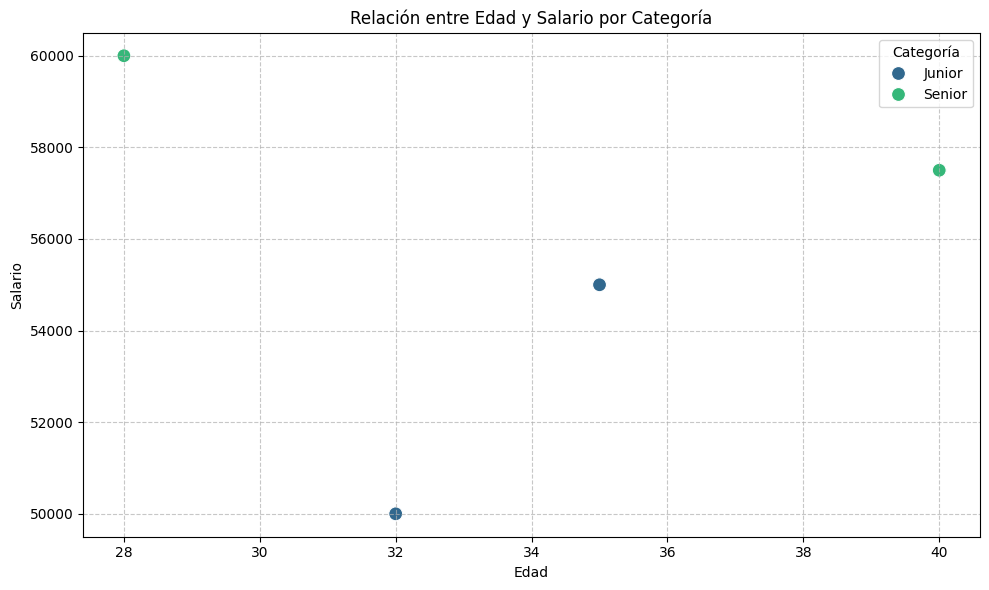

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1 - RELACIÓN EDAD Y SUELDO CON COLORES DE CATEGORÍA

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Edad', y='Salario', hue='Categoría', palette='viridis', s=100)
plt.title('Relación entre Edad y Salario por Categoría')
plt.xlabel('Edad')
plt.ylabel('Salario')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Categoría')
plt.tight_layout()
plt.show()

/tmp/ipykernel_15299/1065196133.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Categoría', y='Salario', palette='viridis')


<Axes: xlabel='Categoría', ylabel='Salario'>

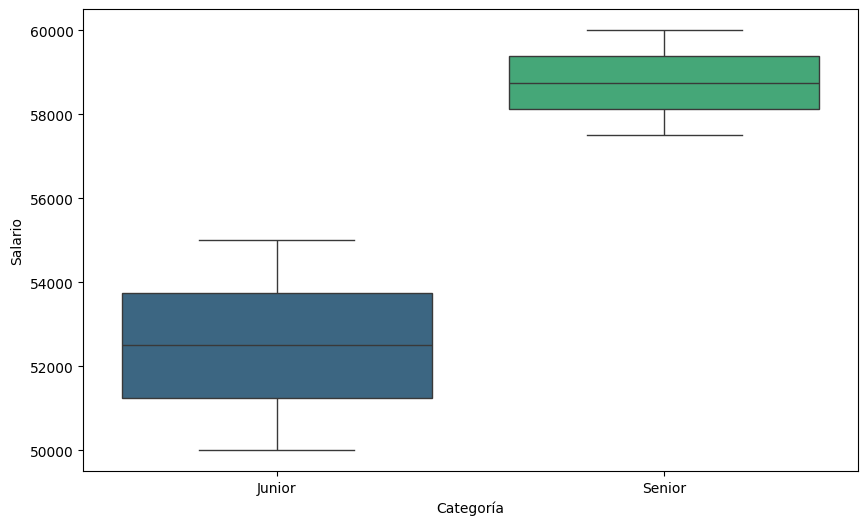

In [83]:
# 2 - SUELDO SEGÚN CATEGORÍA

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Categoría', y='Salario', palette='viridis')

/tmp/ipykernel_15299/1392655971.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Nivel_Educativo', y='Salario', palette='viridis')


<Axes: xlabel='Nivel_Educativo', ylabel='Salario'>

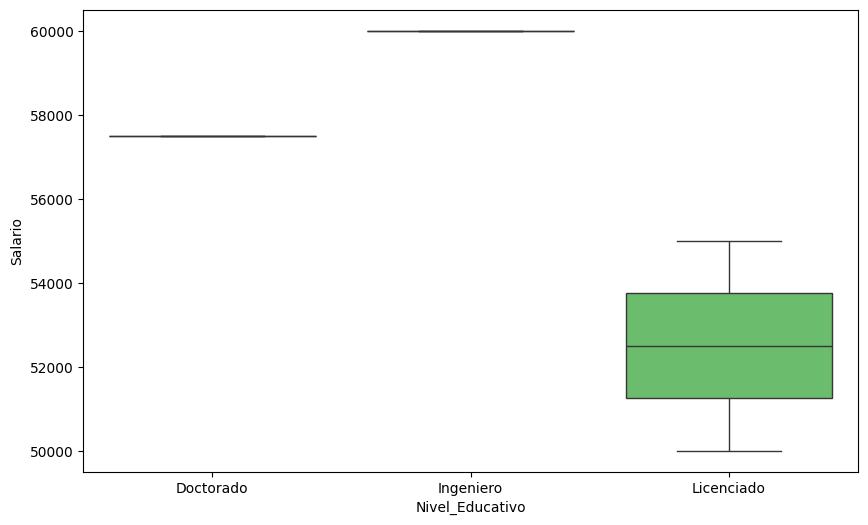

In [84]:
# 3 - SUELDO SEGÚN NIVEL EDUCATIVO

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Nivel_Educativo', y='Salario', palette='viridis')



<Axes: xlabel='Salario', ylabel='Count'>

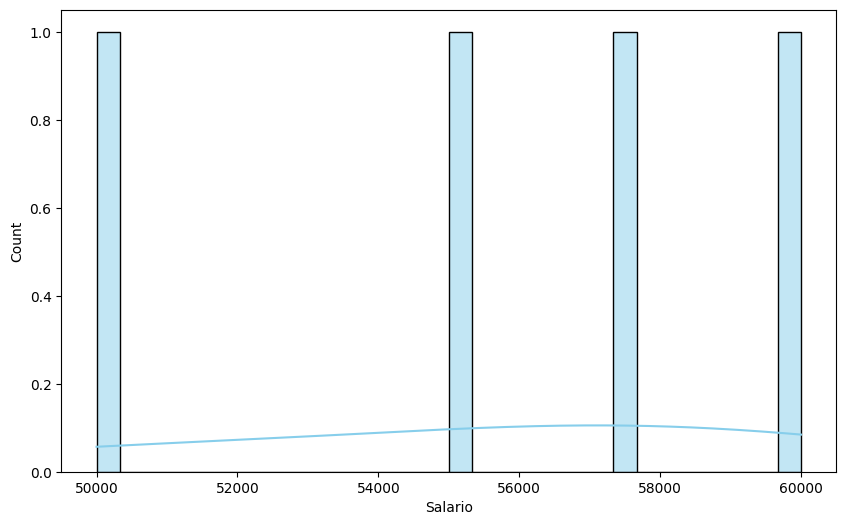

In [85]:
# 4 - HISTOGRAMA DE SUELDOS

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Salario', bins=30, kde=True, color='skyblue')

/tmp/ipykernel_15299/3043468755.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=estado_conteo.index, y=estado_conteo.values, palette='viridis')


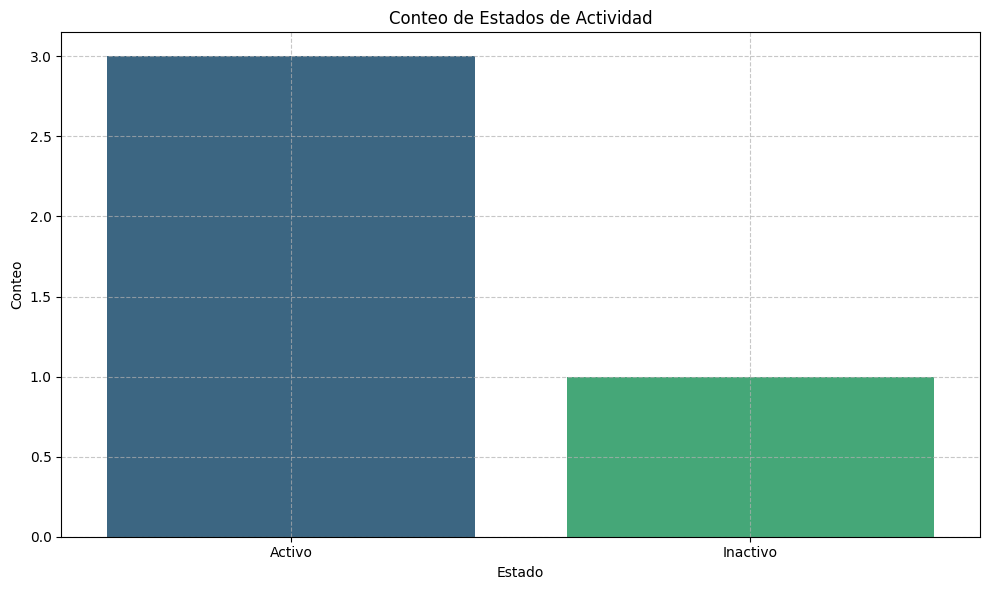

In [88]:
# 5 - ESTADO LABORAL - GRAFICO DE BARRAS

plt.figure(figsize=(10, 6))
estado_conteo = df['Estado'].value_counts()
sns.barplot(x=estado_conteo.index, y=estado_conteo.values, palette='viridis')
plt.title('Conteo de Estados de Actividad')
plt.xlabel('Estado')
plt.ylabel('Conteo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
